# Gaussian Mixture Model via EM: Parent vs Child Heights (Galton Dataset)

**Team:** David (M-step, EM loop, classification) + Audric (data prep, initialization, E-step, log-likelihood)

This notebook loads the Galton family heights dataset, fits a 2-component
Gaussian Mixture Model using an Expectation-Maximization algorithm implemented
from scratch, tracks convergence across iterations, and classifies a new
height as more likely "Child" or "Parent".

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Data Loading, Initialization & E-Step (Audric)

In [2]:
def load_heights(filepath, compare="mother", child_gender=None):
    df = pd.read_csv(filepath, index_col=0)
    df.columns = df.columns.str.strip().str.lower()

    # deduplicate parents because each parent row repeats per child
    parent_heights = df.drop_duplicates(subset=["family"])[compare].dropna().values

    if child_gender:
        mask = df["gender"].str.lower() == child_gender.lower()
        child_heights = df.loc[mask, "childheight"].dropna().values
    else:
        child_heights = df["childheight"].dropna().values

    heights = np.concatenate([parent_heights, child_heights])

    print(f"Parents: {len(parent_heights)} | Children: {len(child_heights)} | Total: {len(heights)}")
    print(f"Min: {heights.min():.2f}  Max: {heights.max():.2f}  Mean: {heights.mean():.2f}")

    return heights


def initialize_parameters(heights, seed=42):
    rng = np.random.default_rng(seed)

    idx = rng.choice(len(heights), size=2, replace=False)
    mu1, mu2 = float(heights[idx[0]]), float(heights[idx[1]])

    if mu1 > mu2:
        mu1, mu2 = mu2, mu1

    variance = float(np.var(heights))

    params = {
        "mu1": mu1,
        "mu2": mu2,
        "sigma1_sq": variance,
        "sigma2_sq": variance,
        "pi1": 0.5,
        "pi2": 0.5,
    }

    print(f"Init -> mu1={mu1:.2f}  mu2={mu2:.2f}  var={variance:.2f}  pi1=0.5  pi2=0.5")
    return params


def gaussian_pdf(x, mu, sigma_sq):
    sigma_sq = max(sigma_sq, 1e-6)
    coefficient = 1.0 / np.sqrt(2.0 * np.pi * sigma_sq)
    exponent = -((x - mu) ** 2) / (2.0 * sigma_sq)
    return coefficient * np.exp(exponent)


def e_step(heights, params):
    w1 = params["pi1"] * gaussian_pdf(heights, params["mu1"], params["sigma1_sq"])
    w2 = params["pi2"] * gaussian_pdf(heights, params["mu2"], params["sigma2_sq"])

    total = w1 + w2
    total = np.where(total == 0, 1e-300, total)

    R = np.column_stack([w1 / total, w2 / total])
    return R


def compute_log_likelihood(heights, params):
    w1 = params["pi1"] * gaussian_pdf(heights, params["mu1"], params["sigma1_sq"])
    w2 = params["pi2"] * gaussian_pdf(heights, params["mu2"], params["sigma2_sq"])
    mixture = np.clip(w1 + w2, 1e-300, None)
    return float(np.sum(np.log(mixture)))

## 3. Load the Dataset & Visualize Raw Heights

Choose `compare="father"` or `compare="mother"` below to pick which
parent-child comparison to run. `GaltonFamilies.csv` and `galton.csv` contain
the same underlying data (just different family-ID formatting), so either
file works.

In [3]:
CSV_PATH = "GaltonFamilies.csv"
COMPARE = "father"      # "father" or "mother"
CHILD_GENDER = None     # None = all children, or "male"/"female" to filter

data = load_heights(CSV_PATH, compare=COMPARE, child_gender=CHILD_GENDER)

Parents: 205 | Children: 934 | Total: 1139
Min: 56.00  Max: 79.00  Mean: 67.21


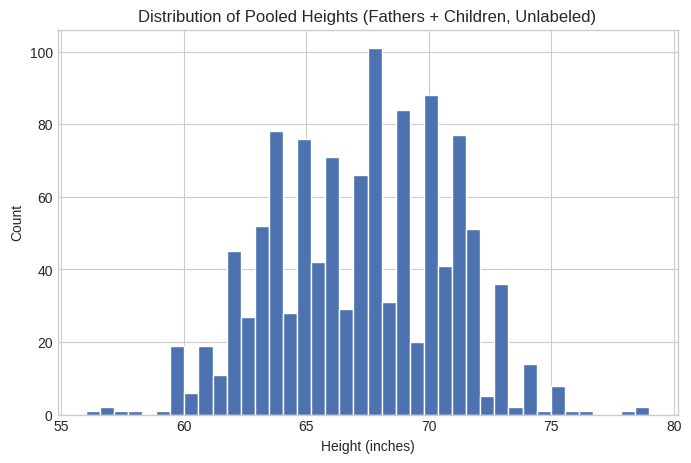

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, color="#4C72B0", edgecolor="white")
plt.title(f"Distribution of Pooled Heights ({COMPARE.title()}s + Children, Unlabeled)")
plt.xlabel("Height (inches)")
plt.ylabel("Count")
plt.show()

## 4. M-Step, EM Loop & Classification (David)

Note: two small fixes were made here versus the original file so it correctly
calls Audric's functions: `compute_log_likelihood` (not `log_likelihood`),
and unpacking Audric's `e_step` output correctly (it returns a single
`(n, 2)` responsibilities array, not a two-item tuple).

In [5]:
def m_step(data, gamma1, gamma2):
    n = len(data)

    N1 = np.sum(gamma1)
    N2 = np.sum(gamma2)

    mu1 = np.sum(gamma1 * data) / N1
    mu2 = np.sum(gamma2 * data) / N2

    sigma1_sq = np.sum(gamma1 * (data - mu1) ** 2) / N1
    sigma2_sq = np.sum(gamma2 * (data - mu2) ** 2) / N2

    pi1 = N1 / n
    pi2 = N2 / n

    return {
        "mu1": float(mu1),
        "mu2": float(mu2),
        "sigma1_sq": float(sigma1_sq),
        "sigma2_sq": float(sigma2_sq),
        "pi1": float(pi1),
        "pi2": float(pi2),
    }


def run_em(data, init_params, max_iters=50, tol=1e-6, verbose=True):
    params = dict(init_params)
    history = []

    ll0 = compute_log_likelihood(data, params)
    history.append({"iteration": 0, **params, "log_likelihood": ll0})
    if verbose:
        _print_row(history[-1])

    prev_ll = ll0
    for it in range(1, max_iters + 1):
        R = e_step(data, params)
        gamma1, gamma2 = R[:, 0], R[:, 1]
        params = m_step(data, gamma1, gamma2)
        ll = compute_log_likelihood(data, params)

        history.append({"iteration": it, **params, "log_likelihood": ll})
        if verbose:
            _print_row(history[-1])

        if abs(ll - prev_ll) < tol:
            if verbose:
                print(f"\nConverged after {it} iterations "
                      f"(log-likelihood change < {tol}).")
            break
        prev_ll = ll

    return params, history


def _print_row(row):
    print(
        f"Iter {row['iteration']:>2} | "
        f"mu1={row['mu1']:.4f}  mu2={row['mu2']:.4f} | "
        f"s1^2={row['sigma1_sq']:.4f}  s2^2={row['sigma2_sq']:.4f} | "
        f"pi1={row['pi1']:.4f}  pi2={row['pi2']:.4f} | "
        f"LL={row['log_likelihood']:.4f}"
    )


def classify(height, params, label1="Child", label2="Parent"):
    p1 = params["pi1"] * gaussian_pdf(height, params["mu1"], params["sigma1_sq"])
    p2 = params["pi2"] * gaussian_pdf(height, params["mu2"], params["sigma2_sq"])
    total = p1 + p2

    posterior1 = p1 / total
    posterior2 = p2 / total

    return {label1: float(posterior1), label2: float(posterior2)}

## 5. Run EM and Build the Tracking Table

In [6]:
init_params = initialize_parameters(data, seed=42)
final_params, history = run_em(data, init_params, max_iters=50, tol=1e-6)

tracking_table = pd.DataFrame(history)
tracking_table.head(3)  # iteration 0, 1, 2 -- required for the assignment

Init -> mu1=63.50  mu2=69.00  var=12.72  pi1=0.5  pi2=0.5
Iter  0 | mu1=63.5000  mu2=69.0000 | s1^2=12.7241  s2^2=12.7241 | pi1=0.5000  pi2=0.5000 | LL=-3143.4682
Iter  1 | mu1=64.9174  mu2=68.9259 | s1^2=8.6931  s2^2=8.8613 | pi1=0.4284  pi2=0.5716 | LL=-3058.0741
Iter  2 | mu1=64.8527  mu2=68.9794 | s1^2=8.4043  s2^2=8.6633 | pi1=0.4291  pi2=0.5709 | LL=-3057.1672
Iter  3 | mu1=64.7861  mu2=69.0338 | s1^2=8.1196  s2^2=8.4403 | pi1=0.4297  pi2=0.5703 | LL=-3056.1623
Iter  4 | mu1=64.7189  mu2=69.0885 | s1^2=7.8316  s2^2=8.2035 | pi1=0.4302  pi2=0.5698 | LL=-3055.0704
Iter  5 | mu1=64.6522  mu2=69.1429 | s1^2=7.5410  s2^2=7.9596 | pi1=0.4308  pi2=0.5692 | LL=-3053.9169
Iter  6 | mu1=64.5874  mu2=69.1958 | s1^2=7.2521  s2^2=7.7147 | pi1=0.4312  pi2=0.5688 | LL=-3052.7411
Iter  7 | mu1=64.5258  mu2=69.2463 | s1^2=6.9712  s2^2=7.4747 | pi1=0.4317  pi2=0.5683 | LL=-3051.5934
Iter  8 | mu1=64.4687  mu2=69.2933 | s1^2=6.7051  s2^2=7.2456 | pi1=0.4321  pi2=0.5679 | LL=-3050.5285
Iter  9 | mu1

,iteration,mu1,mu2,sigma1_sq,sigma2_sq,pi1,pi2,log_likelihood
0,0,63.500000,69.000000,12.724063,12.724063,0.500000,0.500000,-3143.468242
1,1,64.917401,68.925938,8.693119,8.861312,0.428441,0.571559,-3058.074059
2,2,64.852728,68.979430,8.404286,8.663329,0.429135,0.570865,-3057.167166


## 6. Visualize Convergence

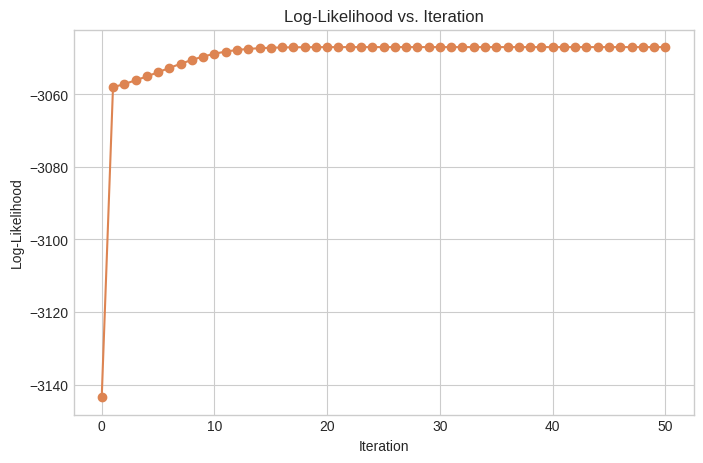

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(tracking_table["iteration"], tracking_table["log_likelihood"],
         marker="o", color="#DD8452")
plt.title("Log-Likelihood vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.show()

## 7. Visualize the Fitted Mixture vs. Raw Data

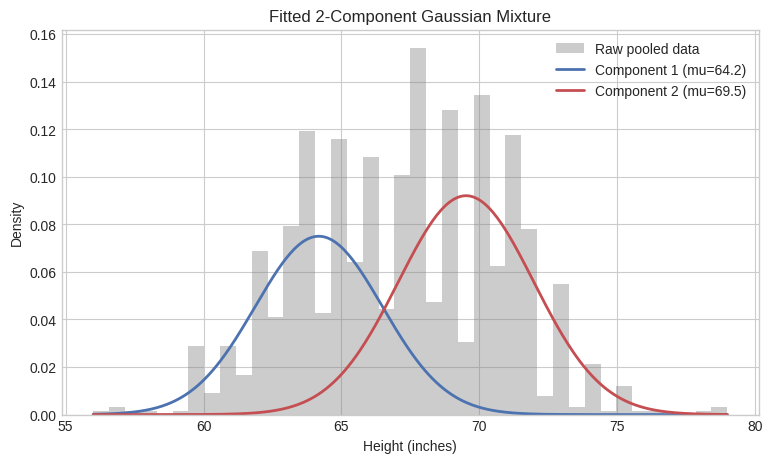

In [8]:
x_range = np.linspace(data.min(), data.max(), 500)
pdf1 = final_params["pi1"] * gaussian_pdf(x_range, final_params["mu1"], final_params["sigma1_sq"])
pdf2 = final_params["pi2"] * gaussian_pdf(x_range, final_params["mu2"], final_params["sigma2_sq"])

plt.figure(figsize=(9, 5))
plt.hist(data, bins=40, density=True, alpha=0.4, color="gray", label="Raw pooled data")
plt.plot(x_range, pdf1, color="#4C72B0", linewidth=2, label=f"Component 1 (mu={final_params['mu1']:.1f})")
plt.plot(x_range, pdf2, color="#C44E52", linewidth=2, label=f"Component 2 (mu={final_params['mu2']:.1f})")
plt.title("Fitted 2-Component Gaussian Mixture")
plt.xlabel("Height (inches)")
plt.ylabel("Density")
plt.legend()
plt.show()

## 8. Discussion: Should We Just Split at the Global Mean?

**No.** Splitting at a single global mean assumes both groups have equal
variance and no overlap between them -- neither is true for parent vs. child
heights. EM instead assigns every point a *soft* probability of belonging to
each group, correctly handling the overlap region where a given height could
plausibly belong to either the shorter or taller population.

The cell below makes this concrete: it compares a naive hard threshold at the
mean to the EM posterior for a height sitting right at that boundary.

In [9]:
global_mean = float(np.mean(data))
print(f"Global mean height: {global_mean:.2f}")

test_point = global_mean
naive_label = "Component 1 (100% confident, no nuance)" if test_point < global_mean else "Component 2 (100% confident, no nuance)"
em_result = classify(test_point, final_params, label1="Component 1", label2="Component 2")

print(f"\nNaive mean-split classification of {test_point:.2f}: {naive_label}")
print(f"EM posterior classification of {test_point:.2f}: {em_result}")

Global mean height: 67.21

Naive mean-split classification of 67.21: Component 2 (100% confident, no nuance)
EM posterior classification of 67.21: {'Component 1': 0.34888299282926305, 'Component 2': 0.6511170071707371}


## 9. Live Classification Demo

Run this cell during the presentation with the height the coach gives you.

In [ ]:
if final_params["mu1"] < final_params["mu2"]:
    child_label, parent_label = "Child", "Parent"
else:
    child_label, parent_label = "Parent", "Child"

test_height = float(input("Enter the test height from the coach: "))
result = classify(
    test_height, final_params,
    label1="Child" if final_params["mu1"] < final_params["mu2"] else "Parent",
    label2="Parent" if final_params["mu1"] < final_params["mu2"] else "Child",
)

print(f"\nHeight = {test_height}")
for label, prob in result.items():
    print(f"  P({label}) = {prob:.4f}")